# Module 05 — Integration, Clustering & Annotation

This notebook documents the cross-dataset integration, clustering, and de novo
cell type annotation produced by `scripts/05_integration.py`. The 11 IVD
scRNA-seq datasets (~410K cells, excluding GSE233666) are split by tissue
compartment and integrated using **scVI** with `batch_key='study'`:

- **NP** — Nucleus Pulposus: 262,967 cells from multiple studies
- **AF** — Annulus Fibrosus: 84,624 cells
- **CEP** — Cartilaginous Endplate: 50,858 cells
- **all_cells** — Combined object: 410,759 cells (for cross-compartment analyses)

After scVI integration, Leiden clustering is performed on the integrated
embeddings, followed by de novo annotation using IVD-specific marker gene
signatures. CellTypist is used for validation of non-mesenchymal (immune,
endothelial) subtypes.

**Data sources:**
- `data/integrated/NP.h5ad` — NP compartment (262,967 cells)
- `data/integrated/AF.h5ad` — AF compartment (84,624 cells)
- `data/integrated/CEP.h5ad` — CEP compartment (50,858 cells)
- `data/integrated/all_cells.h5ad` — All compartments combined (410,759 cells)
- `results/integration/celltypist_validation/` — CellTypist concordance tables

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='scanpy')

from pathlib import Path

import anndata
anndata.settings.allow_write_nullable_strings = True

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight'})

# ── Paths ──────────────────────────────────────────────────────────────────
BASE = Path('..').resolve()
INT_DIR = BASE / 'data' / 'integrated'
RESULTS_DIR = BASE / 'results' / 'integration'
CELLTYPIST_DIR = RESULTS_DIR / 'celltypist_validation'
FIG_DIR = RESULTS_DIR
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Compartment files ────────────────────────────────────────────────────
COMPARTMENTS = {
    'NP': INT_DIR / 'NP.h5ad',
    'AF': INT_DIR / 'AF.h5ad',
    'CEP': INT_DIR / 'CEP.h5ad',
    'all_cells': INT_DIR / 'all_cells.h5ad',
}

for name, path in COMPARTMENTS.items():
    if path.exists():
        print(f'  {name}: {path.name} found')
    else:
        print(f'  {name}: NOT FOUND')

  NP: NP.h5ad found
  AF: AF.h5ad found
  CEP: CEP.h5ad found
  all_cells: all_cells.h5ad found


## Helper Function — Compartment UMAP Grid

Each compartment is visualized with three UMAP panels: colored by cell type
(de novo annotation), study of origin, and disease condition. This shows
whether integration successfully mixes batches while preserving biological
cell type structure.

In [2]:
def plot_compartment_umaps(obs_df, umap_coords, compartment, fig_dir,
                          umap_unint=None):
    """Plot UMAP panels for a compartment: cell_type, study, condition.
    
    Uses pre-extracted obs and UMAP coordinates to avoid holding the full
    AnnData in memory.
    """
    color_keys = []
    if 'cell_type' in obs_df.columns:
        color_keys.append('cell_type')
    if 'study' in obs_df.columns:
        color_keys.append('study')
    if 'condition_harmonized' in obs_df.columns:
        color_keys.append('condition_harmonized')

    n_cols = len(color_keys)
    has_unint = umap_unint is not None
    n_rows = 2 if has_unint else 1

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows),
                              squeeze=False)

    idx = np.random.RandomState(42).permutation(len(umap_coords))

    for col_i, color_key in enumerate(color_keys):
        labels = obs_df[color_key].values
        unique_labels = sorted(obs_df[color_key].dropna().unique())
        palette = dict(zip(unique_labels,
                           sns.color_palette('tab20', max(len(unique_labels), 20))))

        # Integrated UMAP (row 0)
        ax = axes[0, col_i]
        colors = [palette.get(str(labels[i]), '#cccccc') for i in idx]
        ax.scatter(umap_coords[idx, 0], umap_coords[idx, 1],
                   c=colors, s=0.3, alpha=0.5, rasterized=True)
        ax.set_xticks([]); ax.set_yticks([])
        title = f'scVI — {color_key}'
        ax.set_title(title, fontsize=10)

        # Legend (only for cell_type)
        if color_key == 'cell_type':
            handles = [Line2D([0], [0], marker='o', color='w',
                              markerfacecolor=palette[t], markersize=6, label=t)
                       for t in unique_labels if t in palette]
            ax.legend(handles=handles, loc='upper left', fontsize=6,
                      frameon=False, markerscale=0.8,
                      bbox_to_anchor=(1.01, 1))

        # Unintegrated UMAP (row 1)
        if has_unint:
            ax2 = axes[1, col_i]
            colors2 = [palette.get(str(labels[i]), '#cccccc') for i in idx]
            ax2.scatter(umap_unint[idx, 0], umap_unint[idx, 1],
                        c=colors2, s=0.3, alpha=0.5, rasterized=True)
            ax2.set_xticks([]); ax2.set_yticks([])
            ax2.set_title(f'Unintegrated — {color_key}', fontsize=10)

    fig.suptitle(f'{compartment}: scVI Integration Results', fontsize=14, y=1.01)
    fig.tight_layout()
    fig.savefig(fig_dir / f'notebook_05_{compartment}_umap.png',
                dpi=150, bbox_inches='tight')
    plt.show()


def load_compartment_lightweight(path, compartment):
    """Load obs and UMAP from a compartment h5ad without loading .X."""
    adata = sc.read_h5ad(path, backed='r')
    obs_df = adata.obs.to_memory() if hasattr(adata.obs, 'to_memory') else adata.obs.copy()
    umap_coords = adata.obsm['X_umap'][:] if 'X_umap' in adata.obsm else None
    umap_unint = adata.obsm['X_umap_unintegrated'][:] if 'X_umap_unintegrated' in adata.obsm else None
    shape = adata.shape
    obsm_keys = list(adata.obsm.keys())
    adata.file.close()
    print(f'{compartment}: {shape[0]:,} cells x {shape[1]:,} genes')
    print(f'  obsm keys: {obsm_keys}')
    if 'cell_type' in obs_df.columns:
        print(f'  Cell types: {obs_df["cell_type"].nunique()}')
        print(obs_df['cell_type'].value_counts().to_string())
    if 'study' in obs_df.columns:
        print(f'  Studies: {obs_df["study"].nunique()}')
    print()
    return obs_df, umap_coords, umap_unint

## NP Compartment — Nucleus Pulposus

The NP compartment contains 262,967 cells integrated with scVI. De novo
annotation identifies NP subtypes (mature chondrocyte, fibrocartilaginous)
and non-mesenchymal populations (T cells, macrophages, pericytes, B cells)
that co-occur in NP tissue samples.

NP: 262,967 cells x 11,033 genes
  obsm keys: ['X_pca', 'X_pca_unintegrated', 'X_scvi_mesenchymal', 'X_scvi_non_mesenchymal', 'X_umap', 'X_umap_unintegrated']
  Cell types: 9
cell_type
NP_mature_chondrocyte    129207
NP_fibrocartilaginous     78081
NP_notochordal            21555
unassigned                12207
NP_stressed_degen          9704
T_cell                     6174
Macrophage                 3750
Pericyte_SMC               1295
B_cell                      994
  Studies: 8



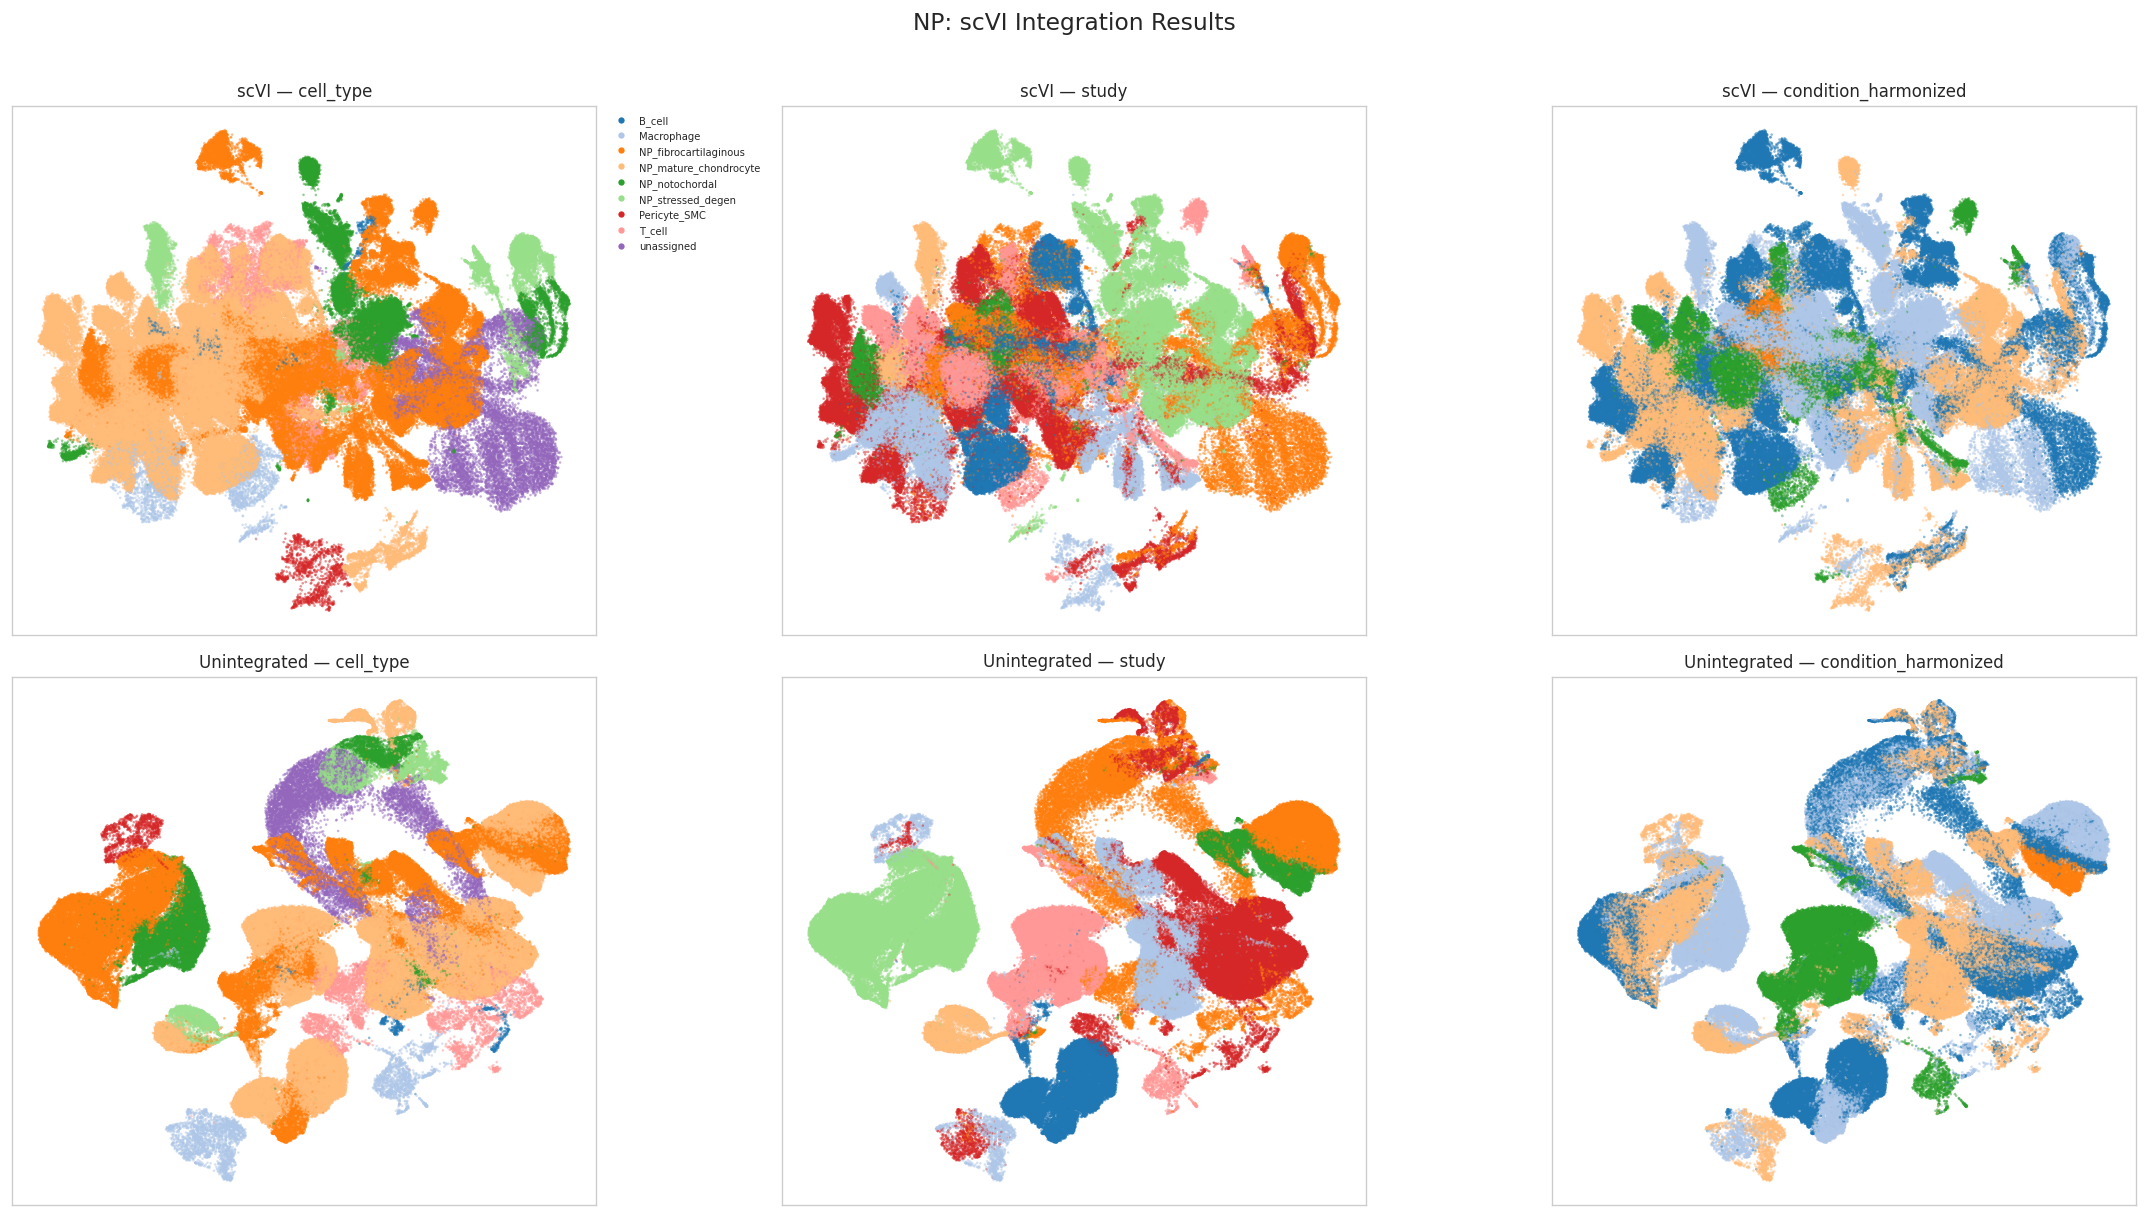

In [3]:
np_path = COMPARTMENTS['NP']
if np_path.exists():
    np_obs, np_umap, np_umap_unint = load_compartment_lightweight(np_path, 'NP')
    plot_compartment_umaps(np_obs, np_umap, 'NP', FIG_DIR, umap_unint=np_umap_unint)
    del np_umap, np_umap_unint  # free memory, keep obs for later
else:
    np_obs = None
    print('NP compartment file not found')

## AF Compartment — Annulus Fibrosus

The AF compartment contains 84,624 cells. De novo annotation distinguishes
AF_inner and AF_outer subtypes along with minor non-mesenchymal populations
(pericytes, endothelial).

AF: 84,610 cells x 15,537 genes
  obsm keys: ['X_pca', 'X_pca_unintegrated', 'X_scvi_AF_mesenchymal', 'X_scvi_mesenchymal', 'X_umap', 'X_umap_scvi_AF_mesenchymal', 'X_umap_unintegrated']
  Cell types: 3
cell_type
AF_outer                49543
AF_inner                20152
AF_mechanical_stress    14915
  Studies: 3



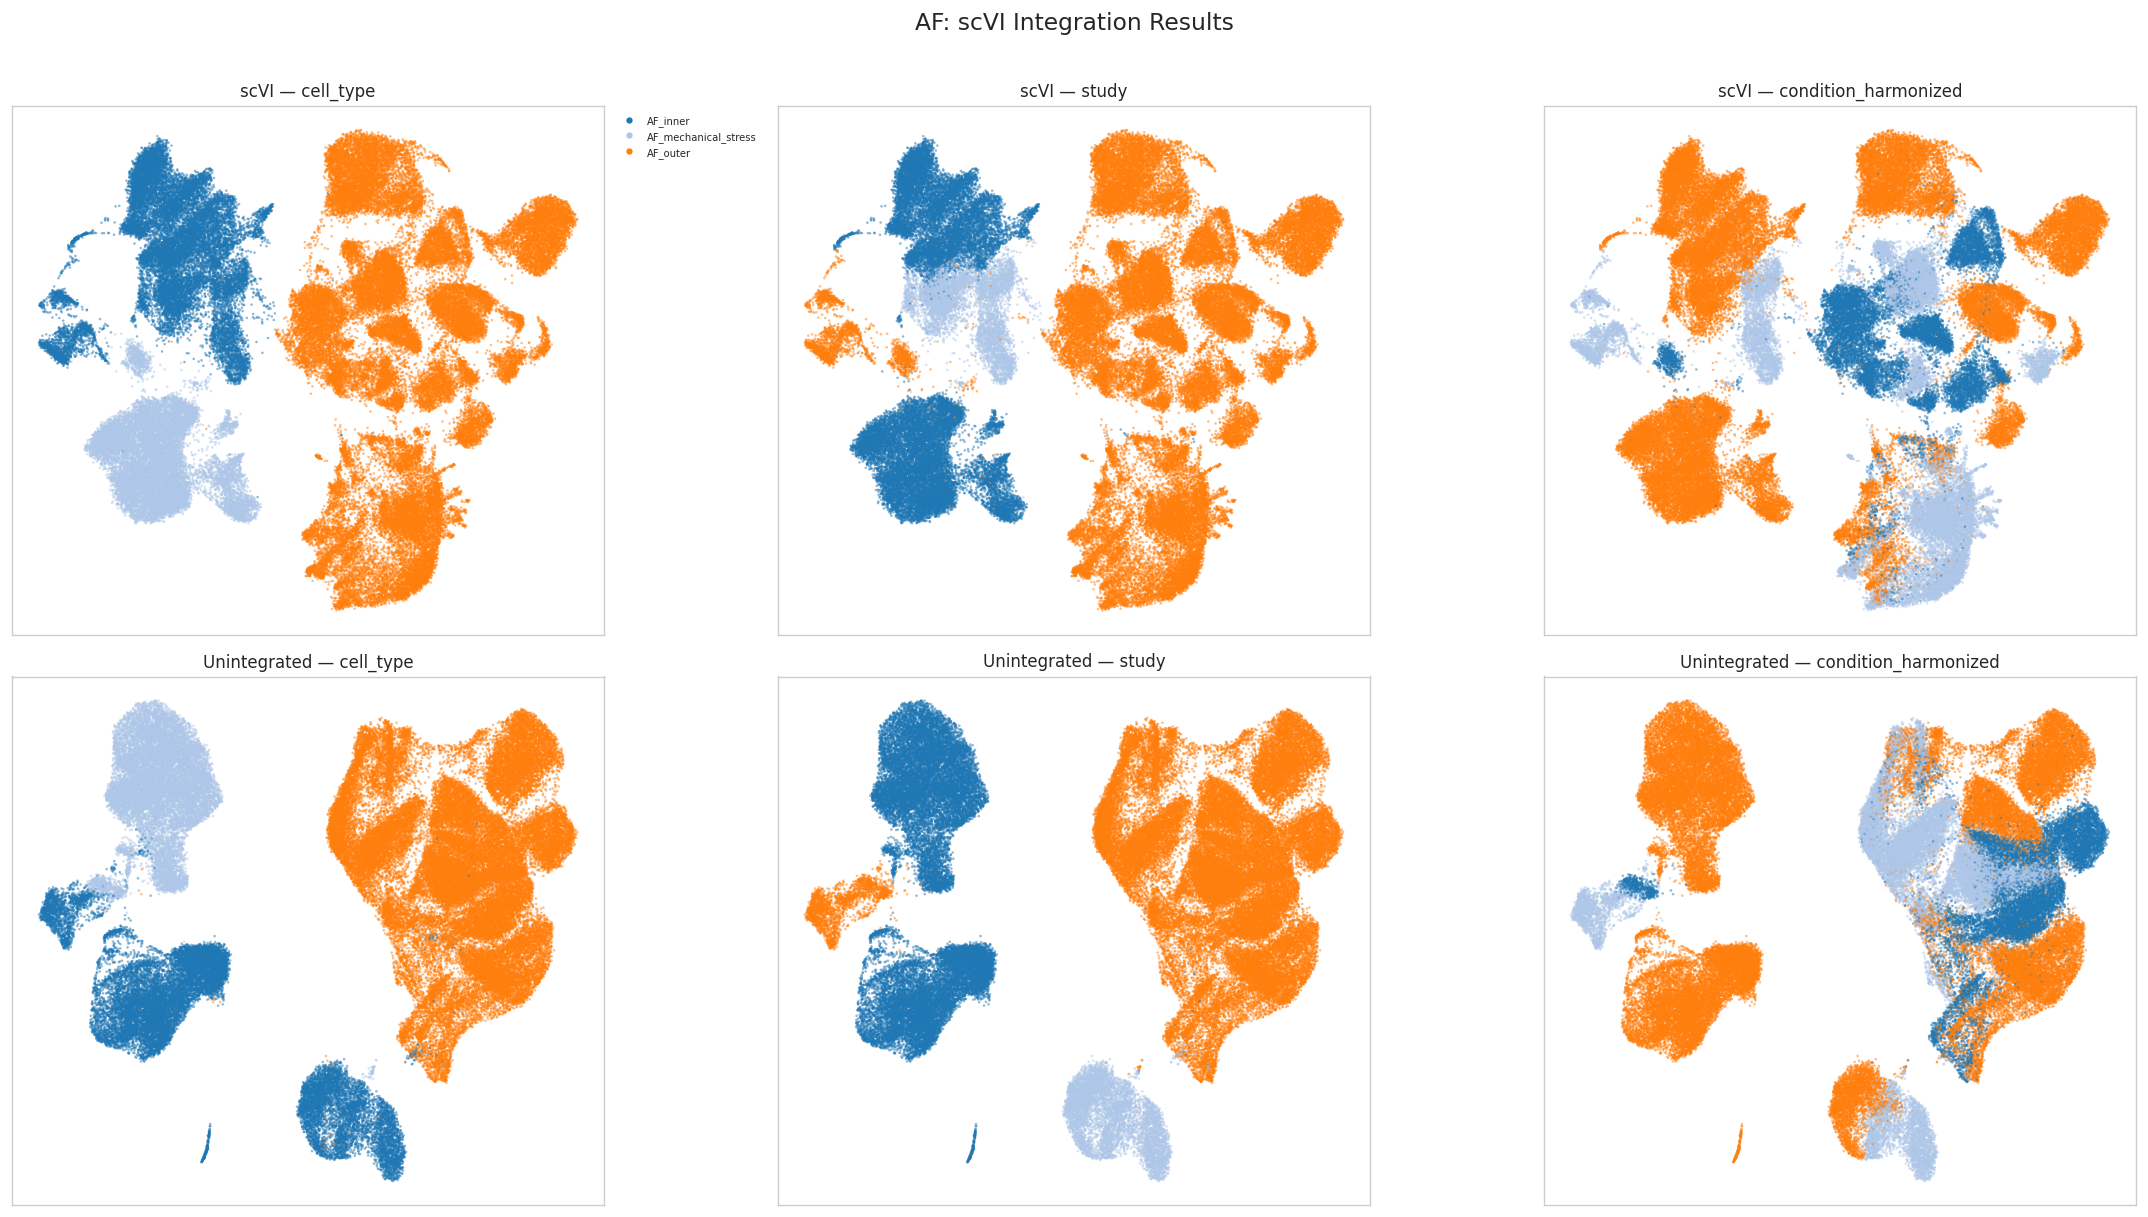

In [4]:
af_path = COMPARTMENTS['AF']
if af_path.exists():
    af_obs, af_umap, af_umap_unint = load_compartment_lightweight(af_path, 'AF')
    plot_compartment_umaps(af_obs, af_umap, 'AF', FIG_DIR, umap_unint=af_umap_unint)
    del af_umap, af_umap_unint
else:
    af_obs = None
    print('AF compartment file not found')

## CEP Compartment — Cartilaginous Endplate

The CEP compartment contains 50,858 cells. De novo annotation identifies
EP_hyaline and EP_ossification subtypes plus minor non-mesenchymal populations.

CEP: 50,714 cells x 17,862 genes
  obsm keys: ['X_pca', 'X_pca_unintegrated', 'X_scvi_CEP_mesenchymal', 'X_scvi_mesenchymal', 'X_umap', 'X_umap_scvi_CEP_mesenchymal', 'X_umap_unintegrated']
  Cell types: 2
cell_type
EP_hyaline         34258
EP_ossification    16456
  Studies: 3



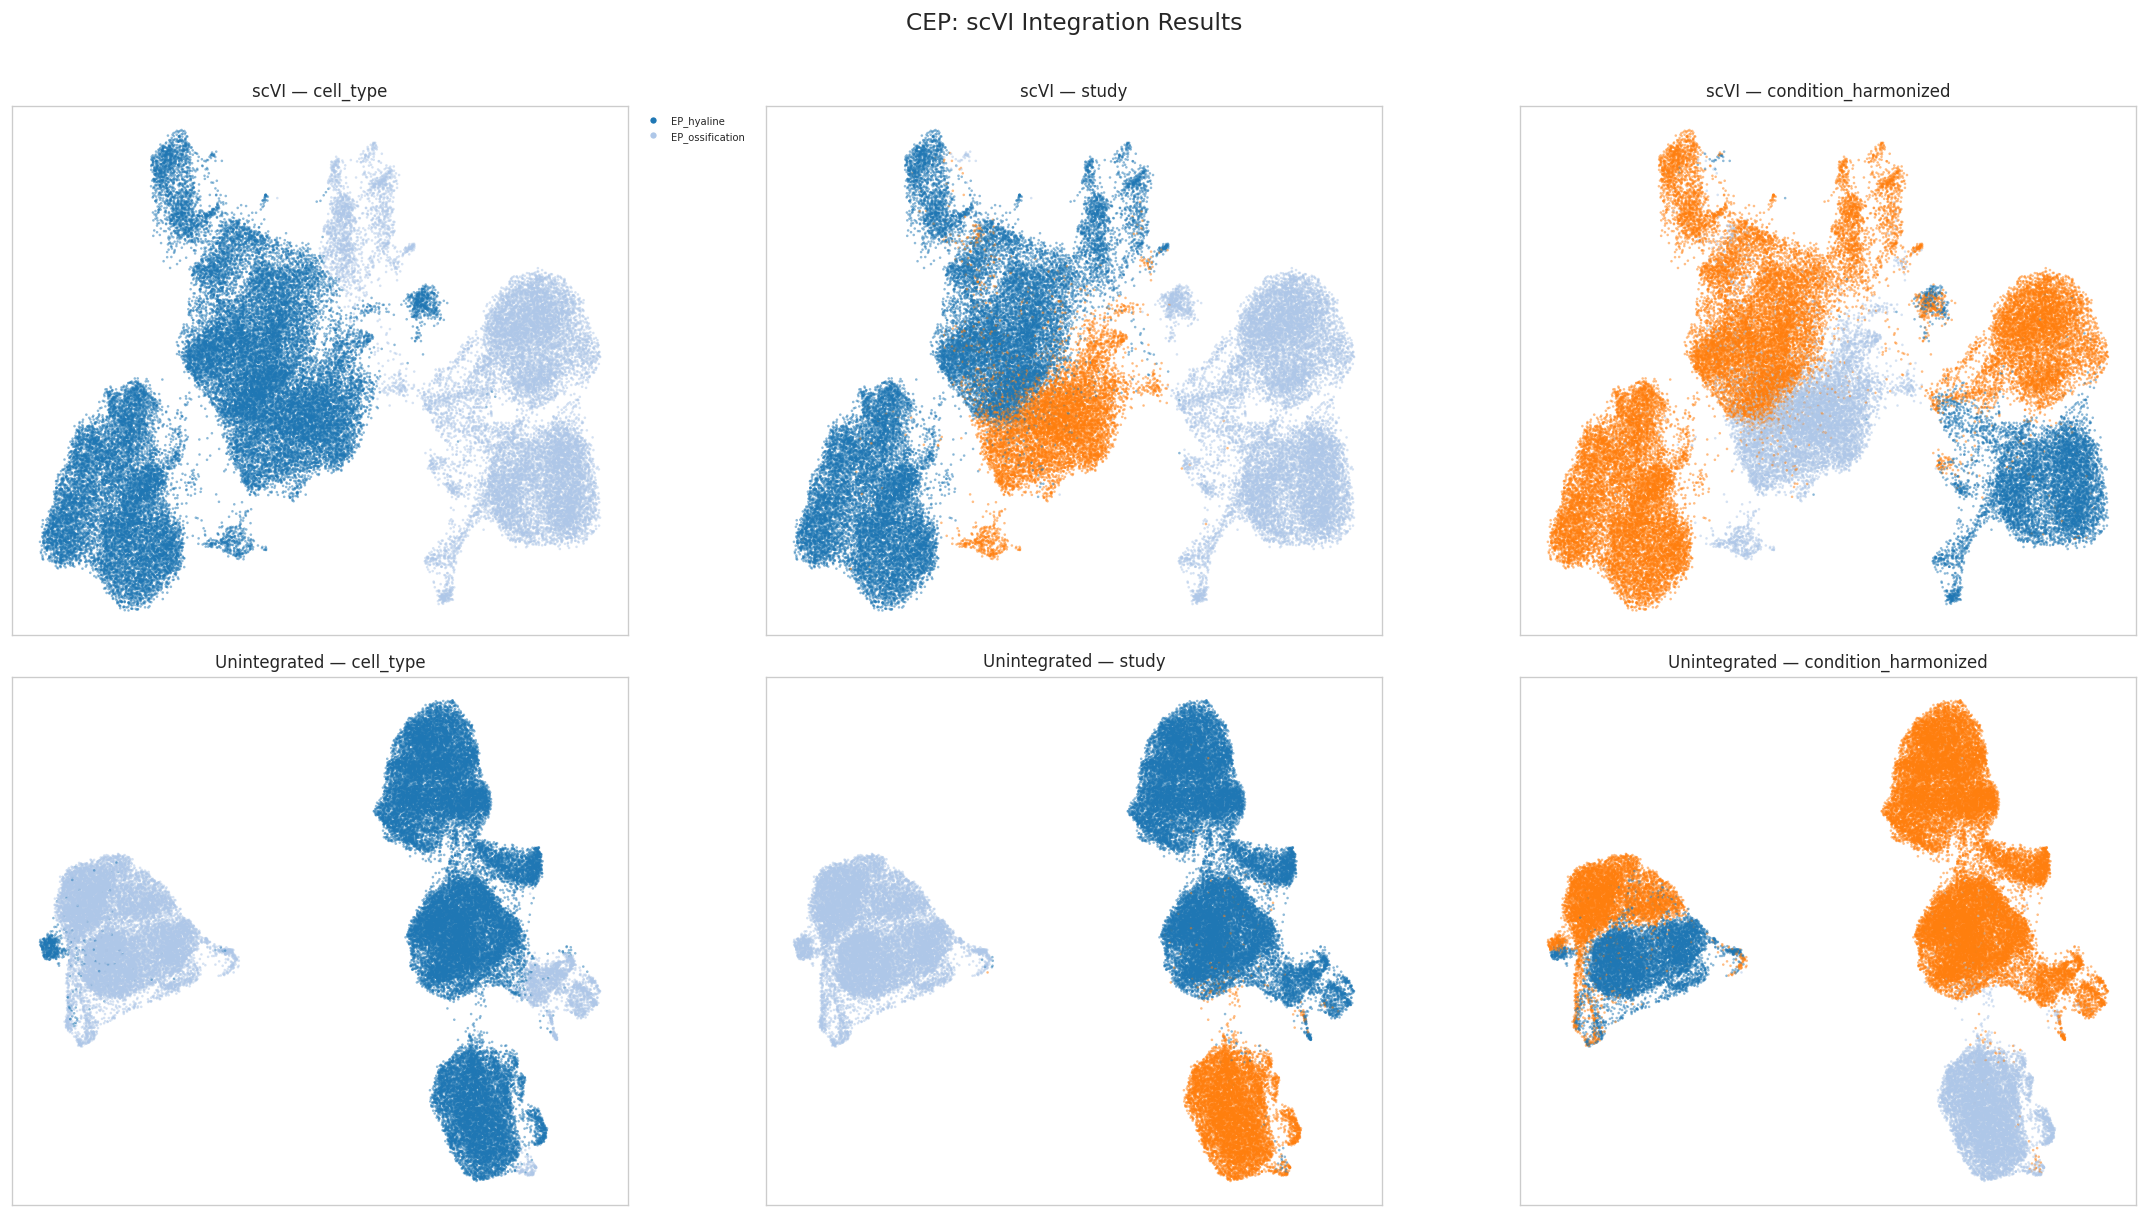

In [5]:
cep_path = COMPARTMENTS['CEP']
if cep_path.exists():
    cep_obs, cep_umap, cep_umap_unint = load_compartment_lightweight(cep_path, 'CEP')
    plot_compartment_umaps(cep_obs, cep_umap, 'CEP', FIG_DIR, umap_unint=cep_umap_unint)
    del cep_umap, cep_umap_unint
else:
    cep_obs = None
    print('CEP compartment file not found')

## Cell Type Proportions Across Compartments

Summary of cell type composition within each compartment object. This shows
the relative abundance of each annotated cell type and highlights the
dominance of mesenchymal populations in the IVD.

compartment,AF,CEP,NP,TOTAL
cell_type,,,,
NP_mature_chondrocyte,0,0,129207,129207
NP_fibrocartilaginous,0,0,78081,78081
AF_outer,49543,0,0,49543
EP_hyaline,0,34258,0,34258
NP_notochordal,0,0,21555,21555
AF_inner,20152,0,0,20152
EP_ossification,0,16456,0,16456
AF_mechanical_stress,14915,0,0,14915
unassigned,0,0,12207,12207


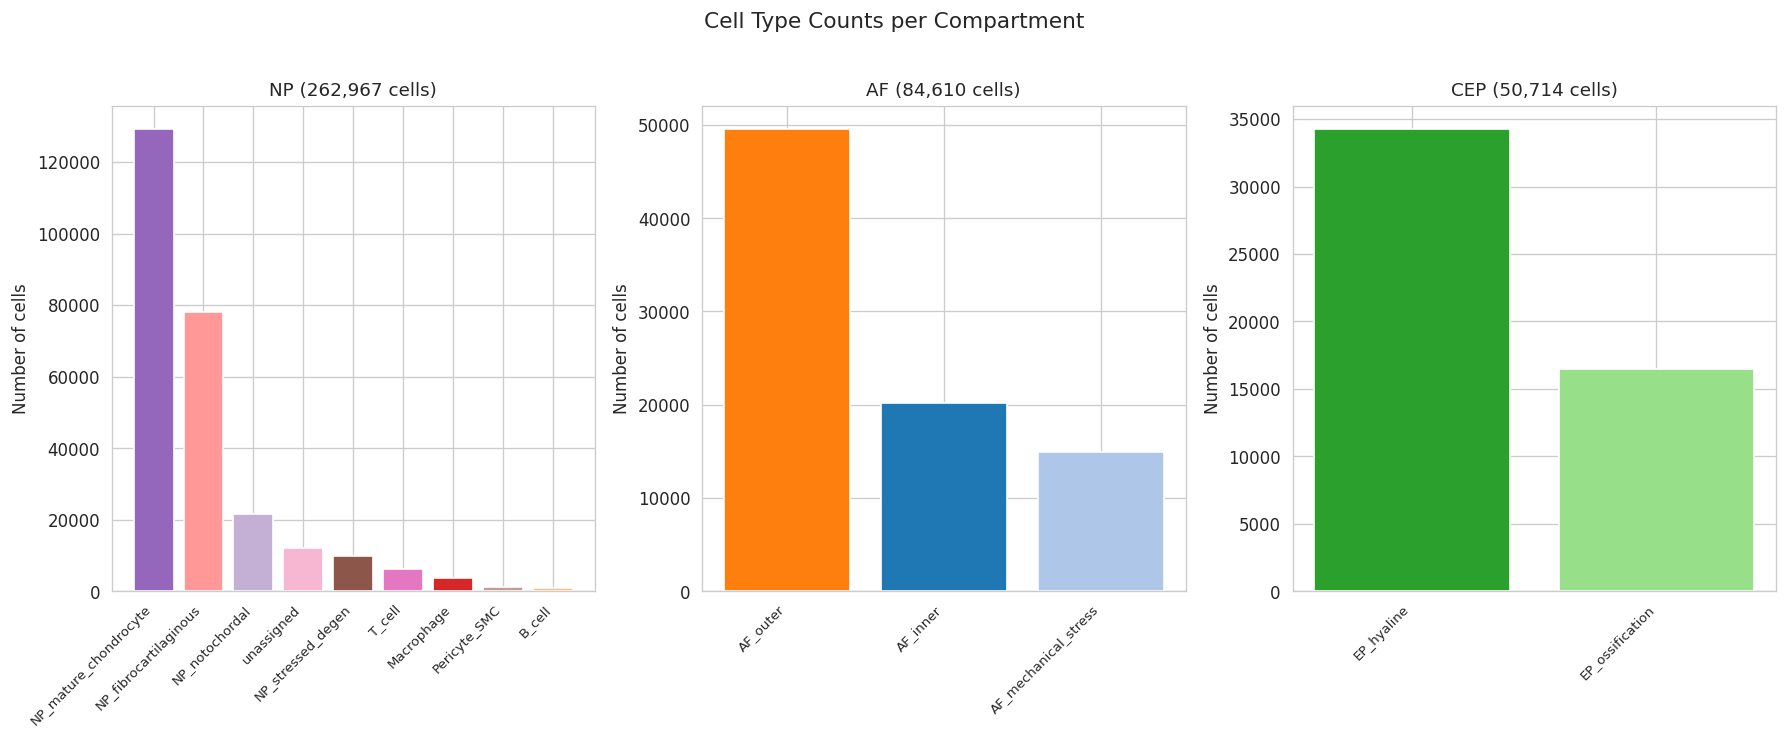

In [6]:
# Collect cell type proportions from each compartment
compartment_obs = {'NP': np_obs, 'AF': af_obs, 'CEP': cep_obs}
compartment_obs = {k: v for k, v in compartment_obs.items() if v is not None}

prop_records = []
for comp, obs in compartment_obs.items():
    if 'cell_type' not in obs.columns:
        continue
    n = len(obs)
    for ct, cnt in obs['cell_type'].value_counts().items():
        prop_records.append({
            'compartment': comp, 'cell_type': ct,
            'count': cnt, 'proportion': cnt / n
        })

if prop_records:
    prop_df = pd.DataFrame(prop_records)

    # Table view
    pivot = prop_df.pivot_table(index='cell_type', columns='compartment',
                                 values='count', fill_value=0, aggfunc='sum')
    pivot['TOTAL'] = pivot.sum(axis=1)
    pivot = pivot.sort_values('TOTAL', ascending=False)
    display(pivot.style.set_caption('Cell Type Counts by Compartment'))

    # Stacked bar per compartment
    fig, axes = plt.subplots(1, len(compartment_obs), figsize=(5 * len(compartment_obs), 6))
    if len(compartment_obs) == 1:
        axes = [axes]

    all_types = sorted(prop_df['cell_type'].unique())
    palette = dict(zip(all_types, sns.color_palette('tab20', max(len(all_types), 20))))

    for ax, (comp, obs) in zip(axes, compartment_obs.items()):
        counts = obs['cell_type'].value_counts()
        bars = ax.bar(range(len(counts)), counts.values,
                       color=[palette.get(t, '#ccc') for t in counts.index])
        ax.set_xticks(range(len(counts)))
        ax.set_xticklabels(counts.index, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('Number of cells')
        ax.set_title(f'{comp} ({len(obs):,} cells)', fontsize=11)

    fig.suptitle('Cell Type Counts per Compartment', fontsize=13, y=1.02)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'notebook_05_cell_type_proportions.png',
                dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No cell type data available')

## CellTypist Validation

CellTypist (`Immune_All_Low` model) was run on non-mesenchymal clusters to
validate the de novo annotation. The concordance tables below compare the
de novo labels with CellTypist majority voting predictions. Concordance is
expected for immune subtypes (T cells, macrophages, B cells) but CellTypist
is not informative for IVD resident cells (mesenchymal populations).

In [7]:
# Load CellTypist concordance tables
concordance_files = sorted(CELLTYPIST_DIR.glob('*_concordance.tsv'))

if concordance_files:
    for f in concordance_files:
        comp = f.stem.replace('_concordance', '')
        df = pd.read_csv(f, sep='\t')
        print(f'\n--- {comp} CellTypist Concordance ---')
        display(df)

        # Summary: fraction of clusters that are concordant
        n_concordant = df['concordant'].sum() if 'concordant' in df.columns else 0
        n_total = len(df)
        print(f'  Concordant clusters: {n_concordant}/{n_total} '
              f'({n_concordant/n_total*100:.0f}%)')
else:
    print('No CellTypist concordance files found')


--- NP CellTypist Concordance ---


,cluster,n_cells,de_novo_label,celltypist_majority,celltypist_agreement_pct,concordant
0,8,1295,Pericyte_SMC,Fibroblasts,99.6,False
1,3,2139,Macrophage,Endothelial cells,99.9,False
2,1,3297,T_cell,Tcm/Naive helper T cells,30.2,True
3,10,1136,T_cell,Macrophages,63.9,False
4,9,1210,unassigned,Classical monocytes,99.6,False
5,5,1648,T_cell,Classical monocytes,55.0,False
6,13,269,Macrophage,Fibroblasts,82.5,False
7,12,388,B_cell,Naive B cells,99.7,True
8,7,1342,Macrophage,Macrophages,98.8,True
9,0,4952,unassigned,Classical monocytes,100.0,False


  Concordant clusters: 5/16 (31%)


## Study Contribution per Compartment

For each compartment, this shows which studies contribute cells and in what
proportions. Good integration should mix cells from multiple studies within
each cell type cluster.

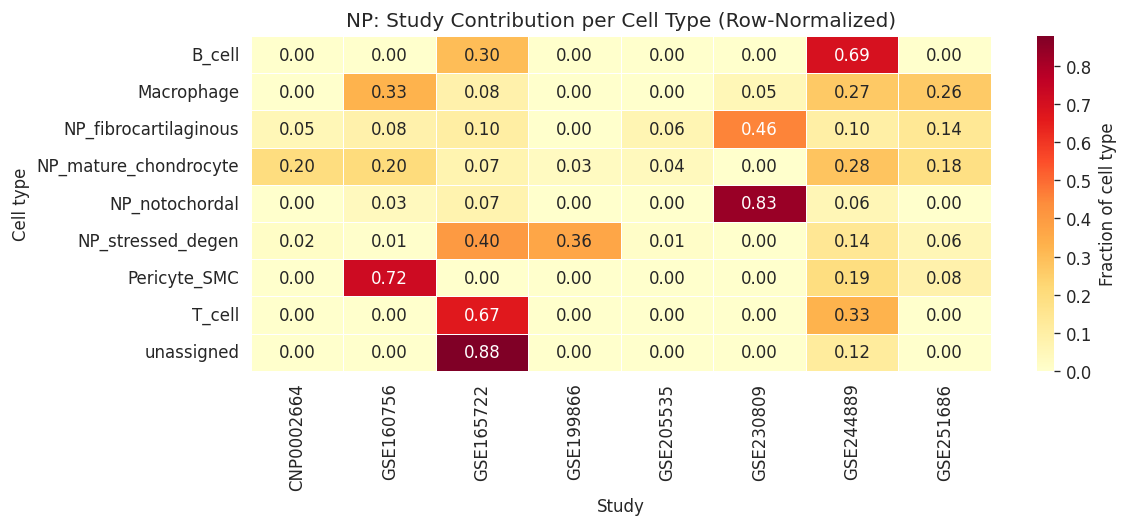

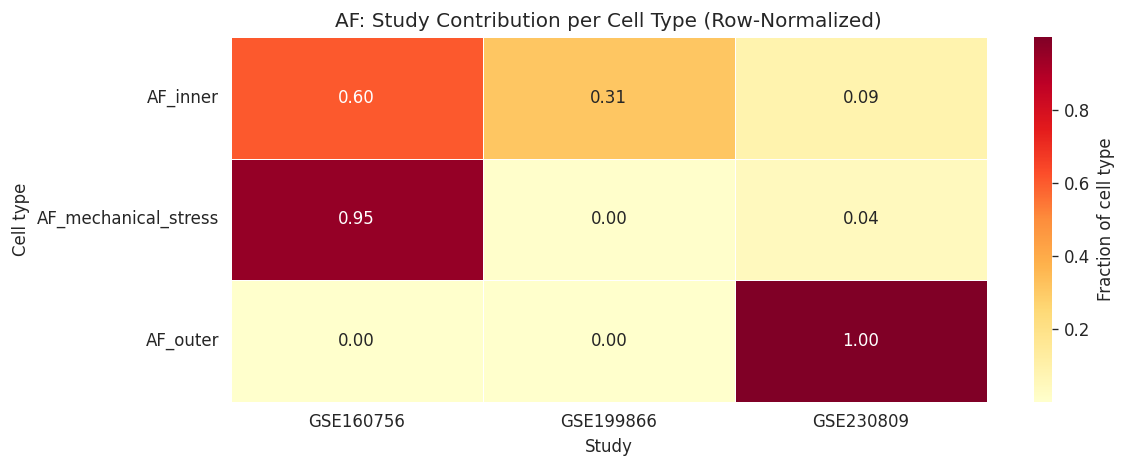

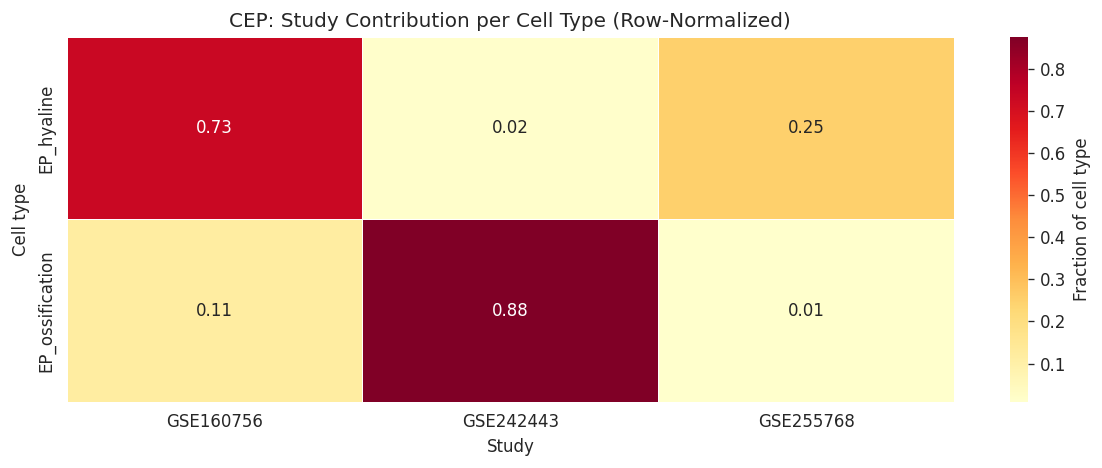

In [8]:
# Study contribution heatmaps per compartment
for comp_name, obs in compartment_obs.items():
    if 'study' not in obs.columns or 'cell_type' not in obs.columns:
        continue

    # Cross-tabulation: cell_type x study
    ct_study = pd.crosstab(obs['cell_type'], obs['study'])
    # Normalize by row (cell type)
    ct_study_norm = ct_study.div(ct_study.sum(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(max(10, ct_study_norm.shape[1] * 0.8),
                                    max(4, ct_study_norm.shape[0] * 0.5)))
    sns.heatmap(ct_study_norm, cmap='YlOrRd', annot=True, fmt='.2f', ax=ax,
                linewidths=0.5, cbar_kws={'label': 'Fraction of cell type'})
    ax.set_xlabel('Study')
    ax.set_ylabel('Cell type')
    ax.set_title(f'{comp_name}: Study Contribution per Cell Type (Row-Normalized)')
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'notebook_05_{comp_name}_study_contribution.png',
                dpi=150, bbox_inches='tight')
    plt.show()

## Condition Distribution per Cell Type

Disease condition (healthy vs degenerated) distribution within each cell
type, split by compartment. This preview informs whether differential
expression analyses in Module 06 will have adequate representation across
conditions.

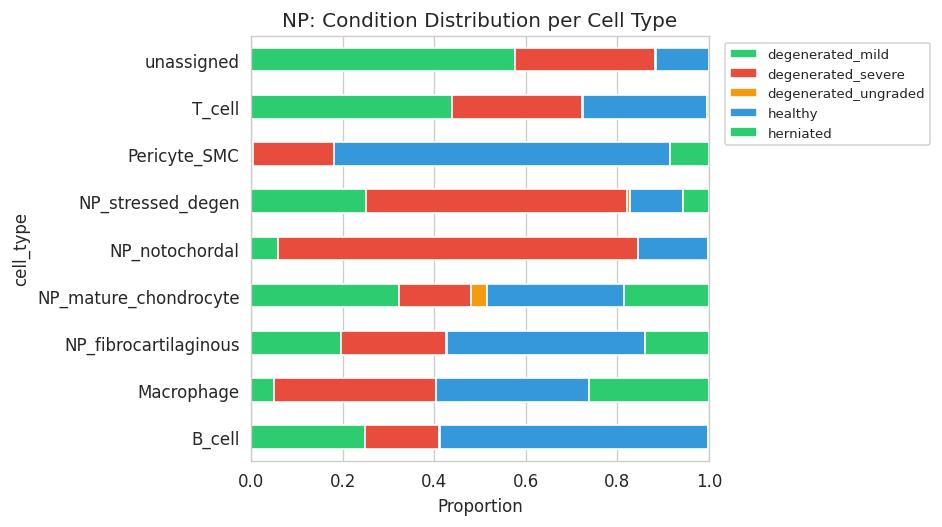

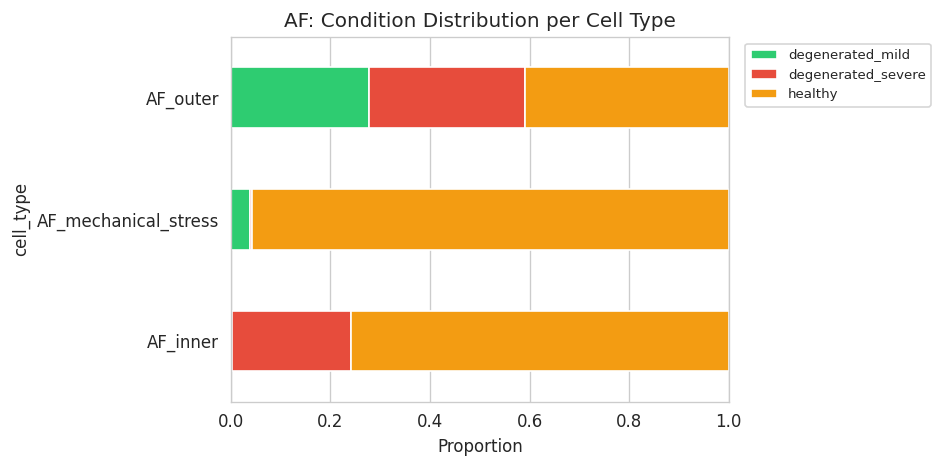

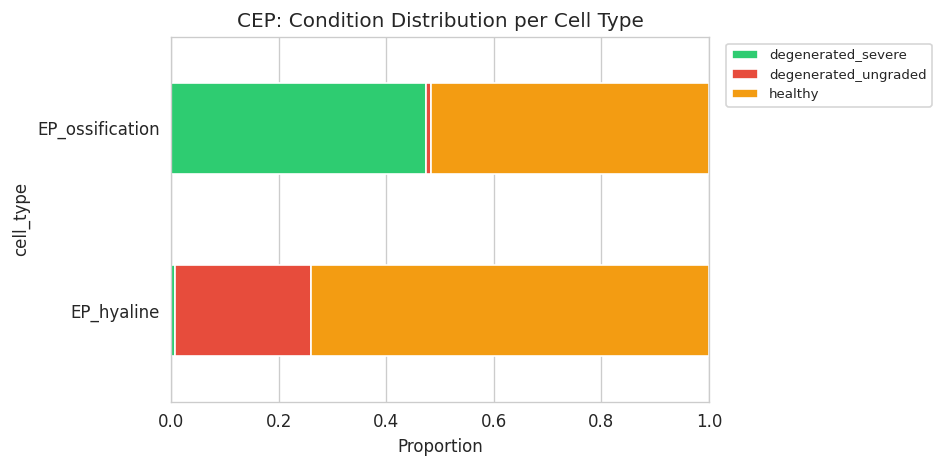

In [9]:
# Condition distribution per cell type per compartment
for comp_name, obs in compartment_obs.items():
    if 'condition_harmonized' not in obs.columns or 'cell_type' not in obs.columns:
        continue

    ct_cond = pd.crosstab(obs['cell_type'], obs['condition_harmonized'])
    ct_cond_norm = ct_cond.div(ct_cond.sum(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(8, max(4, len(ct_cond_norm) * 0.5)))
    ct_cond_norm.plot.barh(stacked=True, ax=ax,
                            color=['#2ecc71', '#e74c3c', '#f39c12', '#3498db'][:ct_cond_norm.shape[1]])
    ax.set_xlabel('Proportion')
    ax.set_title(f'{comp_name}: Condition Distribution per Cell Type')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    ax.set_xlim(0, 1)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'notebook_05_{comp_name}_condition_dist.png',
                dpi=150, bbox_inches='tight')
    plt.show()

## Status — Module 05 Complete

### What was done
- **scVI integration** per compartment (NP, AF, CEP) with `batch_key='study'`
- **Leiden clustering** on scVI latent space
- **De novo annotation** using expanded IVD-specific marker gene signatures
- **CellTypist validation** of non-mesenchymal subtypes (Immune_All_Low model)
- **Combined object** (`all_cells.h5ad`) created for cross-compartment analyses

### Integration approach
- scVI only (single integration approach per compartment)
- Separate scVI models for mesenchymal and non-mesenchymal cells within each compartment
- UMAP computed on scVI latent space

In [10]:
# Clean up large objects
for var_name in ['np_obs', 'af_obs', 'cep_obs', 'compartment_obs']:
    if var_name in dir():
        exec(f'del {var_name}')

saved_figures = sorted(FIG_DIR.glob('notebook_05_*.png'))
print('Saved figures:')
for f in saved_figures:
    print(f'  {f.relative_to(BASE)}')

Saved figures:
  results/integration/notebook_05_AF_condition_dist.png
  results/integration/notebook_05_AF_study_contribution.png
  results/integration/notebook_05_AF_umap.png
  results/integration/notebook_05_CEP_condition_dist.png
  results/integration/notebook_05_CEP_study_contribution.png
  results/integration/notebook_05_CEP_umap.png
  results/integration/notebook_05_NP_condition_dist.png
  results/integration/notebook_05_NP_study_contribution.png
  results/integration/notebook_05_NP_umap.png
  results/integration/notebook_05_cell_type_proportions.png
